<a href="https://colab.research.google.com/github/ducluu2909/Simple_array_autograd/blob/main/Autograd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building an Autograd Engine

*Let's build a mini autograd that can handle arrays.*

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## What is autograd, and why is it needed?

Autograd is the process of calculating the gradient of the trainable parameters (weights and biases) with respect to the loss, so that we can optimize that loss.

## Derivative: a number that tells us what to do

Let's look at the derivative first. In many problems, we want to know how much a quantity y, which is a function of x, changes relative to a change in x.

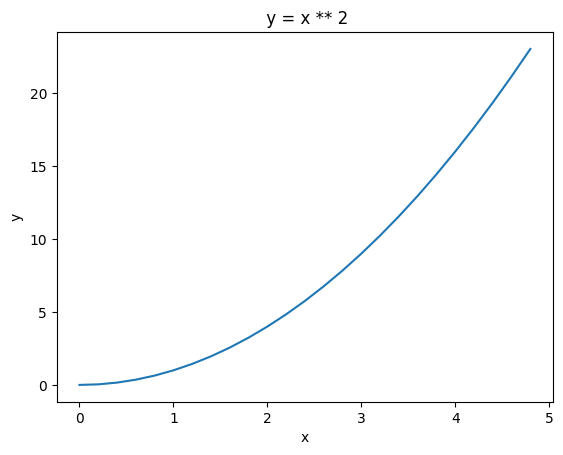

In [ ]:
# let's look at a simple function y = x**2
def f(x):
    y = x** 2
    return y

x = np.arange(0,5,0.2)
y = f(x)
plt.plot(x , y)
plt.title(" y = x ** 2")
plt.xlabel("x")
plt.ylabel("y")

# show the plot
plt.show()

In [ ]:
def derivative(f,x, dx): # returns a scalar that answers: "if I change x by a small amount dx, how does y change?"
    y_before = f(x)
    y_after = f(x + dx)
    dy = (y_after - y_before)
    dy_dx = dy/ dx # the definition of the derivative: change in y / change in x
    return dy_dx

Let's say we want to know how much y changes at x = 2 when we add a small dx = 0.001.

In [ ]:
x = 2
dx = 0.001
derivative(f,x,dx)

4.000999999999699

So at x = 2 the rate of change of y is about 4 times as much as x. If x increases by dx = 0.001, then y increases by dy ≈ 4 · dx.

We can also calculate dy for multiple x at once.

Text(0, 0.5, 'dy')

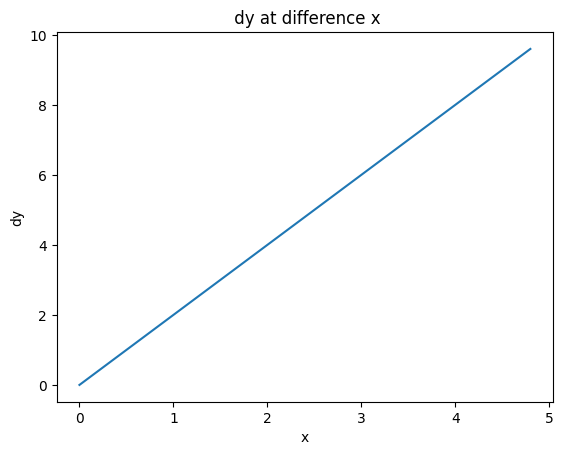

In [ ]:
x = np.arange(0,5,0.2)
dy = derivative(f,x,dx)
plt.plot(x , dy)
plt.title(" dy at difference x")
plt.xlabel("x")
plt.ylabel("dy")


**Observation:** dy looks like a linear function of x, so it should have the form dy = a·x. What is `a`? You can read it off the plot (it is 2), or prove it from the definition.

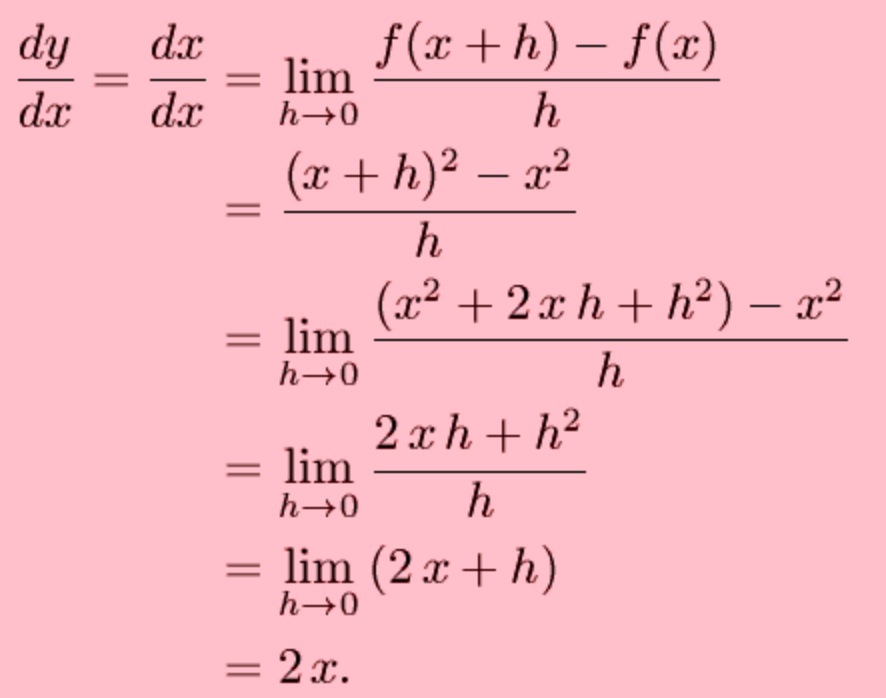

**A big question:** when the derivative equals 0, what does it mean? It means that at that particular x, y stops changing. Why?

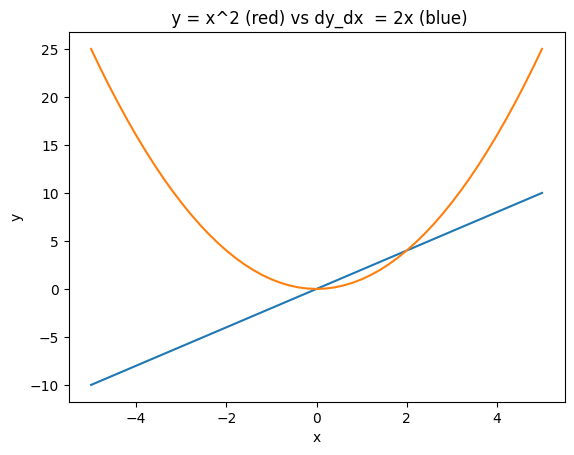

In [ ]:
dx=0.00001

x = np.arange(-5,5.2,0.2)
dy = derivative(f,x,dx)
plt.plot(x , dy)

y = f(x)
plt.plot(x , y)
plt.title(" y = x^2 (red) vs dy_dx  = 2x (blue)")
plt.xlabel("x")
plt.ylabel("y")

# show the plot
plt.show()

This plot shows that where dy/dx = 0, the y curve changes behavior: it goes from dropping in value to increasing.

Imagine we are a person standing on the f(x) curve. If we want to reach the bottom (the lowest y value), we need to go to the point where the derivative is 0.

Look at the blue line again. If we move in the direction opposite to the gradient (when the gradient is < 0 we go right, and vice versa), we will reach the bottom.

This works for most functions. A real model is a big function made of many small ones (matmul, add, relu, square...), so we need a way to get the derivative of the whole thing automatically. That is autograd.

**Recap:** the derivative of y with respect to x tells us the rate of change of y.

## The chain rule, the only trick we need

If `y = f(g(x))`, then `dy/dx = dy/dg * dg/dx`.

So for a big function we do not need one huge formula. Each small op only needs to know its **own local derivative**, and we multiply them together going from the loss back to the inputs:

`grad of input = (grad coming from the output) * (local derivative of this op)`

That is what every `_backward` below does. A `Tensor` remembers:
- `value`: the numbers
- `_child`: the tensors it was made from
- `_ops`: which op made it
- `grad`: d(Loss)/d(this tensor)
- `_backward`: how to push `grad` from this tensor to its children

## The Tensor class



So to make calculate gradient efficetly , we will need a custom data structure for the neural layers.
It will need to be able to :
- store the scalar value in array form.
- remember how it be create, which operation between which member create it.
- Store the gradient so we can do gradient decense on it.
- Some kind of gradient calculate function , define by the operation that create it.


In [ ]:
class Tensor():
    def __init__(self, value, _child=(), _ops=None):
        self.value = np.array(value, dtype=float)
        self._ops = _ops
        self._child = _child
        self.grad = np.zeros_like(self.value)
        self._backward = lambda: None

    def __add__(self, other):
        out = Tensor(self.value + other.value, (self, other), "+")
        def _backward():
            self.grad += out.grad          # d(a+b)/da = 1
            other.grad += out.grad         # d(a+b)/db = 1
        out._backward = _backward
        return out

    def __sub__(self, other):
        out = Tensor(self.value - other.value, (self, other), "-")
        def _backward():
            self.grad += out.grad          # d(a-b)/da = 1
            other.grad -= out.grad         # d(a-b)/db = -1
        out._backward = _backward
        return out

    def __mul__(self, other):
        out = Tensor(self.value * other.value, (self, other), "*")
        def _backward():
            self.grad += other.value * out.grad   # d(a*b)/da = b
            other.grad += self.value * out.grad   # d(a*b)/db = a
        out._backward = _backward
        return out

    def __matmul__(self, other):
        out = Tensor(self.value @ other.value, (self, other), "@")
        def _backward():
            self.grad += out.grad @ other.value.T
            other.grad += self.value.T @ out.grad
        out._backward = _backward
        return out

    def _Relu(self):
        out = Tensor(np.maximum(self.value, 0), (self,), "RELU")
        def _backward():
            self.grad += (self.value > 0) * out.grad   # 1 where input > 0, else 0
        out._backward = _backward
        return out

    def __pow__(self, other):
        out = Tensor(self.value ** other, (self,), "**")
        def _backward():
            self.grad += other * (self.value ** (other - 1)) * out.grad
        out._backward = _backward
        return out

    def T(self):
        return Tensor(self.value.T)

    def __repr__(self) -> str:
        return f"value {self.value} , ops : {self._ops}"

This is a simple Class with some simple operator
It will need to be able to :
- store the scalar value
- store the childs that create it. so we can build some graph based on this , we needed some kind of tree graph for recursion of backward()
- Gradient calculate function  that will be define when a tensor get create based on the operation.


## Running backward in the right order

`_backward` of a tensor can only run **after** all tensors that use it have pushed their grad into it. So we:

1. `build_topo`: walk the graph and list every tensor, children before parents.
2. `Backprop`: reset all grads to 0, set `L.grad = 1` (d L / d L = 1), then call `_backward` in **reversed** order.
3. `SGD`: move each parameter a little **against** its gradient, like walking downhill in the derivative plot above.

Changes from before: I removed the `try/except` in `Backprop` because it hid errors, and `SGD` now takes the list of parameters (before it also "updated" the input `x`, which is pointless).

In [ ]:
def build_topo(root, visited=None, DAG=None):
    if visited is None: visited, DAG = set(), []
    if root not in visited:
        visited.add(root)
        for child in getattr(root, '_child', []) or []:
            build_topo(child, visited, DAG)
        DAG.append(root)
    return DAG

def Backprop(DAG):
    for v in DAG:
        v.grad = np.zeros_like(v.value)
    DAG[-1].grad = np.ones_like(DAG[-1].value)   # d L / d L = 1
    for v in reversed(DAG):
        v._backward()

def SGD(params, lr=1e-3):
    for p in params:
        p.value = p.value - lr * p.grad

## Does it work? Check against the definition of derivative

Remember the very first function in this notebook: `(f(x+dx) - f(x)) / dx`. We can use the same idea to test our autograd. Nudge one weight by a tiny `h`, see how the loss changes, and compare with the gradient autograd gave us. If both match, the engine is correct.

In [ ]:
def forward(x, y, w1, b1, w2):
    a1 = x @ w1
    a2 = a1 + b1
    h1 = a2._Relu()
    y_h = h1 @ w2
    diff = y_h - y
    return diff ** 2

np.random.seed(0)
x  = Tensor(np.random.randn(1, 8))
y  = Tensor([[1.5]])
w1 = Tensor(np.random.randn(8, 3))
b1 = Tensor(np.random.randn(1, 3))
w2 = Tensor(np.random.randn(3, 1))

L = forward(x, y, w1, b1, w2)
Backprop(build_topo(L))

h = 1e-6
for name, p in [("w1", w1), ("b1", b1), ("w2", w2)]:
    num = np.zeros_like(p.value)
    for idx in np.ndindex(*p.value.shape):
        old = p.value[idx]
        p.value[idx] = old + h; L_plus  = forward(x, y, w1, b1, w2).value.item()
        p.value[idx] = old - h; L_minus = forward(x, y, w1, b1, w2).value.item()
        p.value[idx] = old
        num[idx] = (L_plus - L_minus) / (2 * h)
    print(name, "max difference autograd vs numeric:", np.abs(num - p.grad).max())

w1 max difference autograd vs numeric: 4.899760597254499e-09
b1 max difference autograd vs numeric: 1.9688881636170663e-09
w2 max difference autograd vs numeric: 2.0519728138879145e-09


## Visualize the network with Graphviz

Every `Tensor` remembers where it came from (`_child` and `_ops`), so we can draw the computation graph that `build_topo` walks over. Boxes are tensors (with their shape), circles are the operations, and arrows show the forward flow. Leaves (inputs and parameters) are colored.

You need `pip install graphviz` **and** the Graphviz program itself (`sudo apt install graphviz`, or `conda install graphviz`).

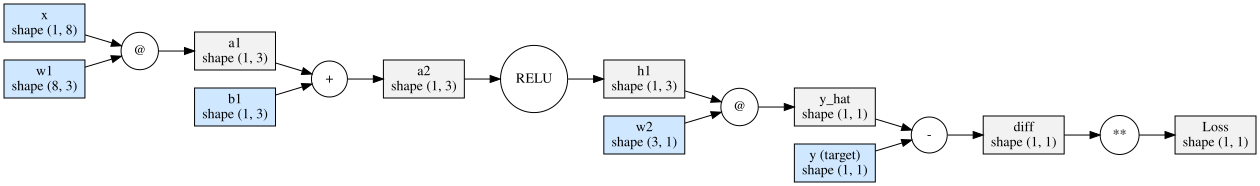

In [ ]:
from graphviz import Digraph

def draw(root, names={}):
    dot = Digraph(graph_attr={"rankdir": "LR"})
    for v in build_topo(root):
        name = names.get(v, "")
        label = f"{name}\nshape {v.value.shape}" if name else f"shape {v.value.shape}"
        leaf = v._ops is None
        dot.node(str(id(v)), label, shape="box",
                 style="filled", fillcolor="#cfe8ff" if leaf else "#f2f2f2")
        if not leaf:  # an op node sits between the children and the result
            dot.node(str(id(v)) + "op", v._ops, shape="circle")
            dot.edge(str(id(v)) + "op", str(id(v)))
            for child in v._child:
                dot.edge(str(id(child)), str(id(v)) + "op")
    return dot

# same network as forward(), but keeping every step so we can name it
x  = Tensor(np.random.randn(1, 8)); y = Tensor([[1.5]])
w1 = Tensor(np.random.randn(8, 3)); b1 = Tensor(np.zeros((1, 3))); w2 = Tensor(np.random.randn(3, 1))
a1 = x @ w1
a2 = a1 + b1
h1 = a2._Relu()
y_h = h1 @ w2
diff = y_h - y
L = diff ** 2

draw(L, {x: "x", y: "y (target)", w1: "w1", b1: "b1", w2: "w2",
         a1: "a1", a2: "a2", h1: "h1", y_h: "y_hat", diff: "diff", L: "Loss"})

## Train on real data

Now the real test: California housing. 8 input features, 1 target (house price). Network: `8 -> 3 (relu) -> 1`, loss = squared error, one sample at a time (plain SGD).

In [ ]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler

data = fetch_california_housing(as_frame=True)
X_raw = data.data.to_numpy()
Y_raw = data.target.to_numpy()

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

Y_t = Y_raw.reshape(-1, 1)

print("X shape:", X.shape)      # (20640, 8) -> 8 input features
print("Y shape:", Y_t.shape)    # (20640, 1) -> 1 target value

X shape: (20640, 8)
Y shape: (20640, 1)


## Training loop

For each sample: forward, build the graph, backward, update. The loss of a single sample is very noisy, so we plot the average over every 200 samples.

In [ ]:
np.random.seed(42)
w1 = Tensor(np.random.randn(8, 3) * np.sqrt(2.0 / 8))
b1 = Tensor(np.zeros((1, 3)))
w2 = Tensor(np.random.randn(3, 1) * np.sqrt(2.0 / 3))
params = [w1, b1, w2]

epochs = 2
losses = []
for epoch in range(epochs):
    for xi, yi in zip(X, Y_t):
        L = forward(Tensor([xi]), Tensor([yi]), w1, b1, w2)
        Backprop(build_topo(L))
        SGD(params, lr=1e-3)
        losses.append(L.value.item())
    print(f"epoch {epoch}: mean loss {np.mean(losses[-len(X):]):.4f}")

epoch 0: mean loss 0.5836
epoch 1: mean loss 0.3311


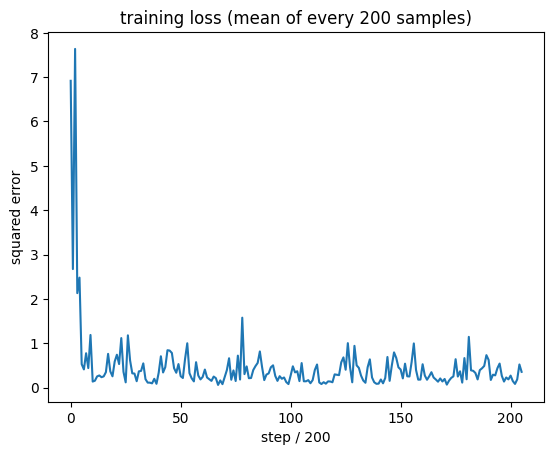

In [ ]:
avg = np.array(losses[:len(losses) // 200 * 200]).reshape(-1, 200).mean(axis=1)
plt.plot(avg)
plt.title("training loss (mean of every 200 samples)")
plt.xlabel("step / 200")
plt.ylabel("squared error")
plt.show()

# Look good to me.



## Recap

- A derivative tells us how much the output changes when the input changes a little.
- Walking against the derivative takes us downhill, towards lower loss.
- For a big function, the **chain rule** lets each small op handle only its own local derivative.
- `Tensor` records the graph while computing forward. `build_topo` orders it, `Backprop` pushes `grad` backwards, `SGD` updates the weights.
- We verified the gradients against the plain `(f(x+h) - f(x-h)) / 2h` definition.

Next steps if you want to go further: mini-batches (needs broadcasting in `+`), more ops (`tanh`, `sum`, `/`), and a bias for the output layer.